In [1]:
import os 
os.environ['CUDA_IS_VISIBLE'] = '0,1'
import sys
import gc
import re
import ctypes
import random
from tqdm import tqdm
import polars as pl

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score,accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

import torch
import torch.nn as nn

from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, AutoConfig

from transformers import Trainer, TrainingArguments
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

2024-05-17 10:13:43.920374: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-17 10:13:43.920498: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-17 10:13:44.053991: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
config = {
    'SEED': 2024,
    'VER': 1,
    'INFERENCE': None,
    'LOAD_MODELS_FROM': None,
    'LOAD_FEATURES_FROM': None,
    'FREEZING_EMBEDDINGS': True,
    'FREEZE_LAYERS': 1,
    'BASE_PATH': '/kaggle/input/medical-text/',
    'PRESET': 'microsoft/deberta-v3-xsmall',
    'MAX_LEN': 512,
    'TRAIN_BATCH': 8,
    'EVAL_BATCH': 16,
    'EPOCHS': 4,
}

In [3]:
Clean = True

def clean_memory():
    if Clean:
        ctypes.CDLL('libc.so.6').malloc_trim(0)
        gc.collect()
        
clean_memory()     

In [4]:
def seed_everything():
    random.seed(config['SEED'])
    os.environ['PYTHONHASHSEED'] = str(config['SEED'])
    np.random.seed(config['SEED'])
    torch.manual_seed(config['SEED'])
    torch.cuda.manual_seed(config['SEED'])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    
seed_everything()

In [5]:
df_train = pd.read_csv(config['BASE_PATH'] +'train.dat', sep='\t', header=None)

In [6]:
df_train.rename(columns = {0: 'conditions', 1: 'full_text'}, inplace=True)

In [7]:
def make_essay_id(row):
    return f'000{row}'

df_train['essay_id'] = df_train.index.map(lambda x: make_essay_id(x))

In [8]:
df_train = df_train[df_train['conditions'] != 5]

1: neoplasms: [세포의 비정상적인 증식] ex) 종양, 암 등..

2: digestive system diseases: [소화계 질병]

3: nervous system diseases: [신경계 질환]

4: cardiovascular diseases: [심혈관계 질병]

의사들은 병원에서 라운드를 돌며 하루에 수십 개 또는 수백 개의 초록을 규칙적으로 스캔하고 환자의 병통을 가리키는 중요한 정보를 빠르게 파악해야 합니다. 고정밀로 문제의 클래스를 식별할 수 있는 보조 기술을 설계

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9633 entries, 0 to 14437
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   conditions  9633 non-null   int64 
 1   full_text   9633 non-null   object
 2   essay_id    9633 non-null   object
dtypes: int64(1), object(2)
memory usage: 301.0+ KB


In [10]:
df_train['label'] = df_train['conditions'] - 1

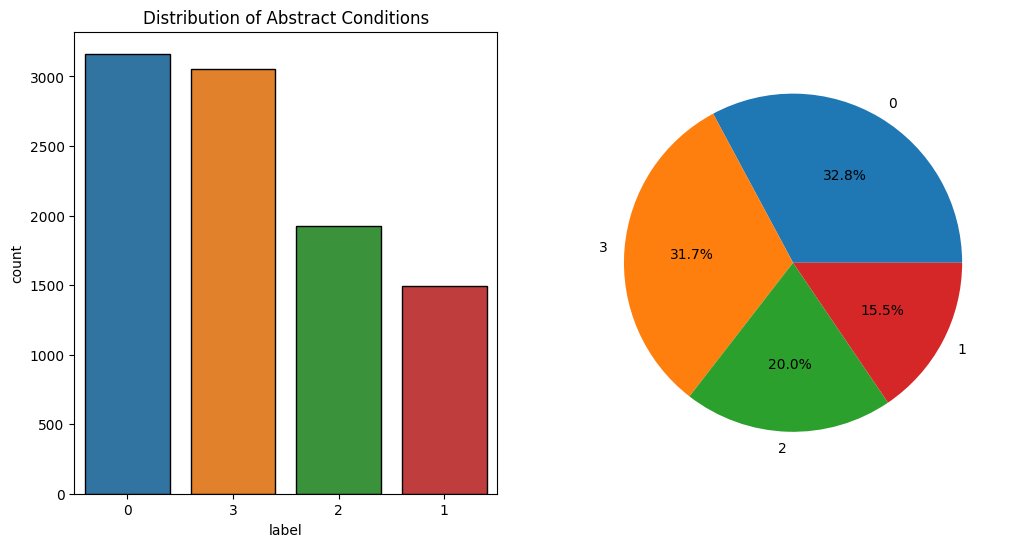

In [11]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Distribution of Abstract Conditions')
sns.countplot(x=df_train['label'], edgecolor='black', order=df_train['label'].value_counts().index)
plt.subplot(1,2,2)
plt.pie(x=df_train['label'].value_counts(), labels=df_train['label'].value_counts().index, autopct='%.1f%%')
plt.show()

In [12]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')

In [13]:
def count_stopwords(text, stopwords):
    text = text.split()
    stopwords_length = len([t for t in text if t in stopwords])
    return stopwords_length

def create_features(df):
    df['letters'] = df['full_text'].apply(lambda x: len(x))
    df['words'] = df['full_text'].apply(lambda x: len(x.split(" ")))
    df['unique_words'] = df['full_text'].apply(lambda x: (len(set(x.split(" ")))))                                   
    df['sentences'] = df['full_text'].apply(lambda x: len(x.split(".")))
    df['stopwords'] = df['full_text'].apply(lambda x: count_stopwords(x, stop_words))
    df['not_stopwords'] = df['words'] - df['stopwords']   
                                               
    return df

In [14]:
tmp = create_features(df_train)

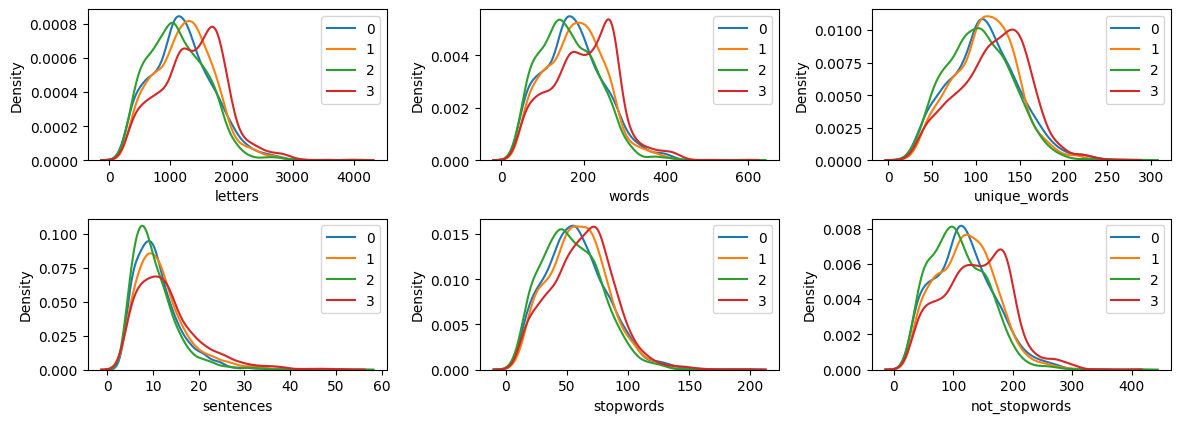

In [15]:
plt.figure(figsize=(12,6))
for i, col in enumerate(tmp.columns[-6:]):
    plt.subplot(3,3,i+1)
    for idx in range(5):
        sns.kdeplot(x=tmp[tmp['label']==idx][col], label=idx)
        plt.legend()

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

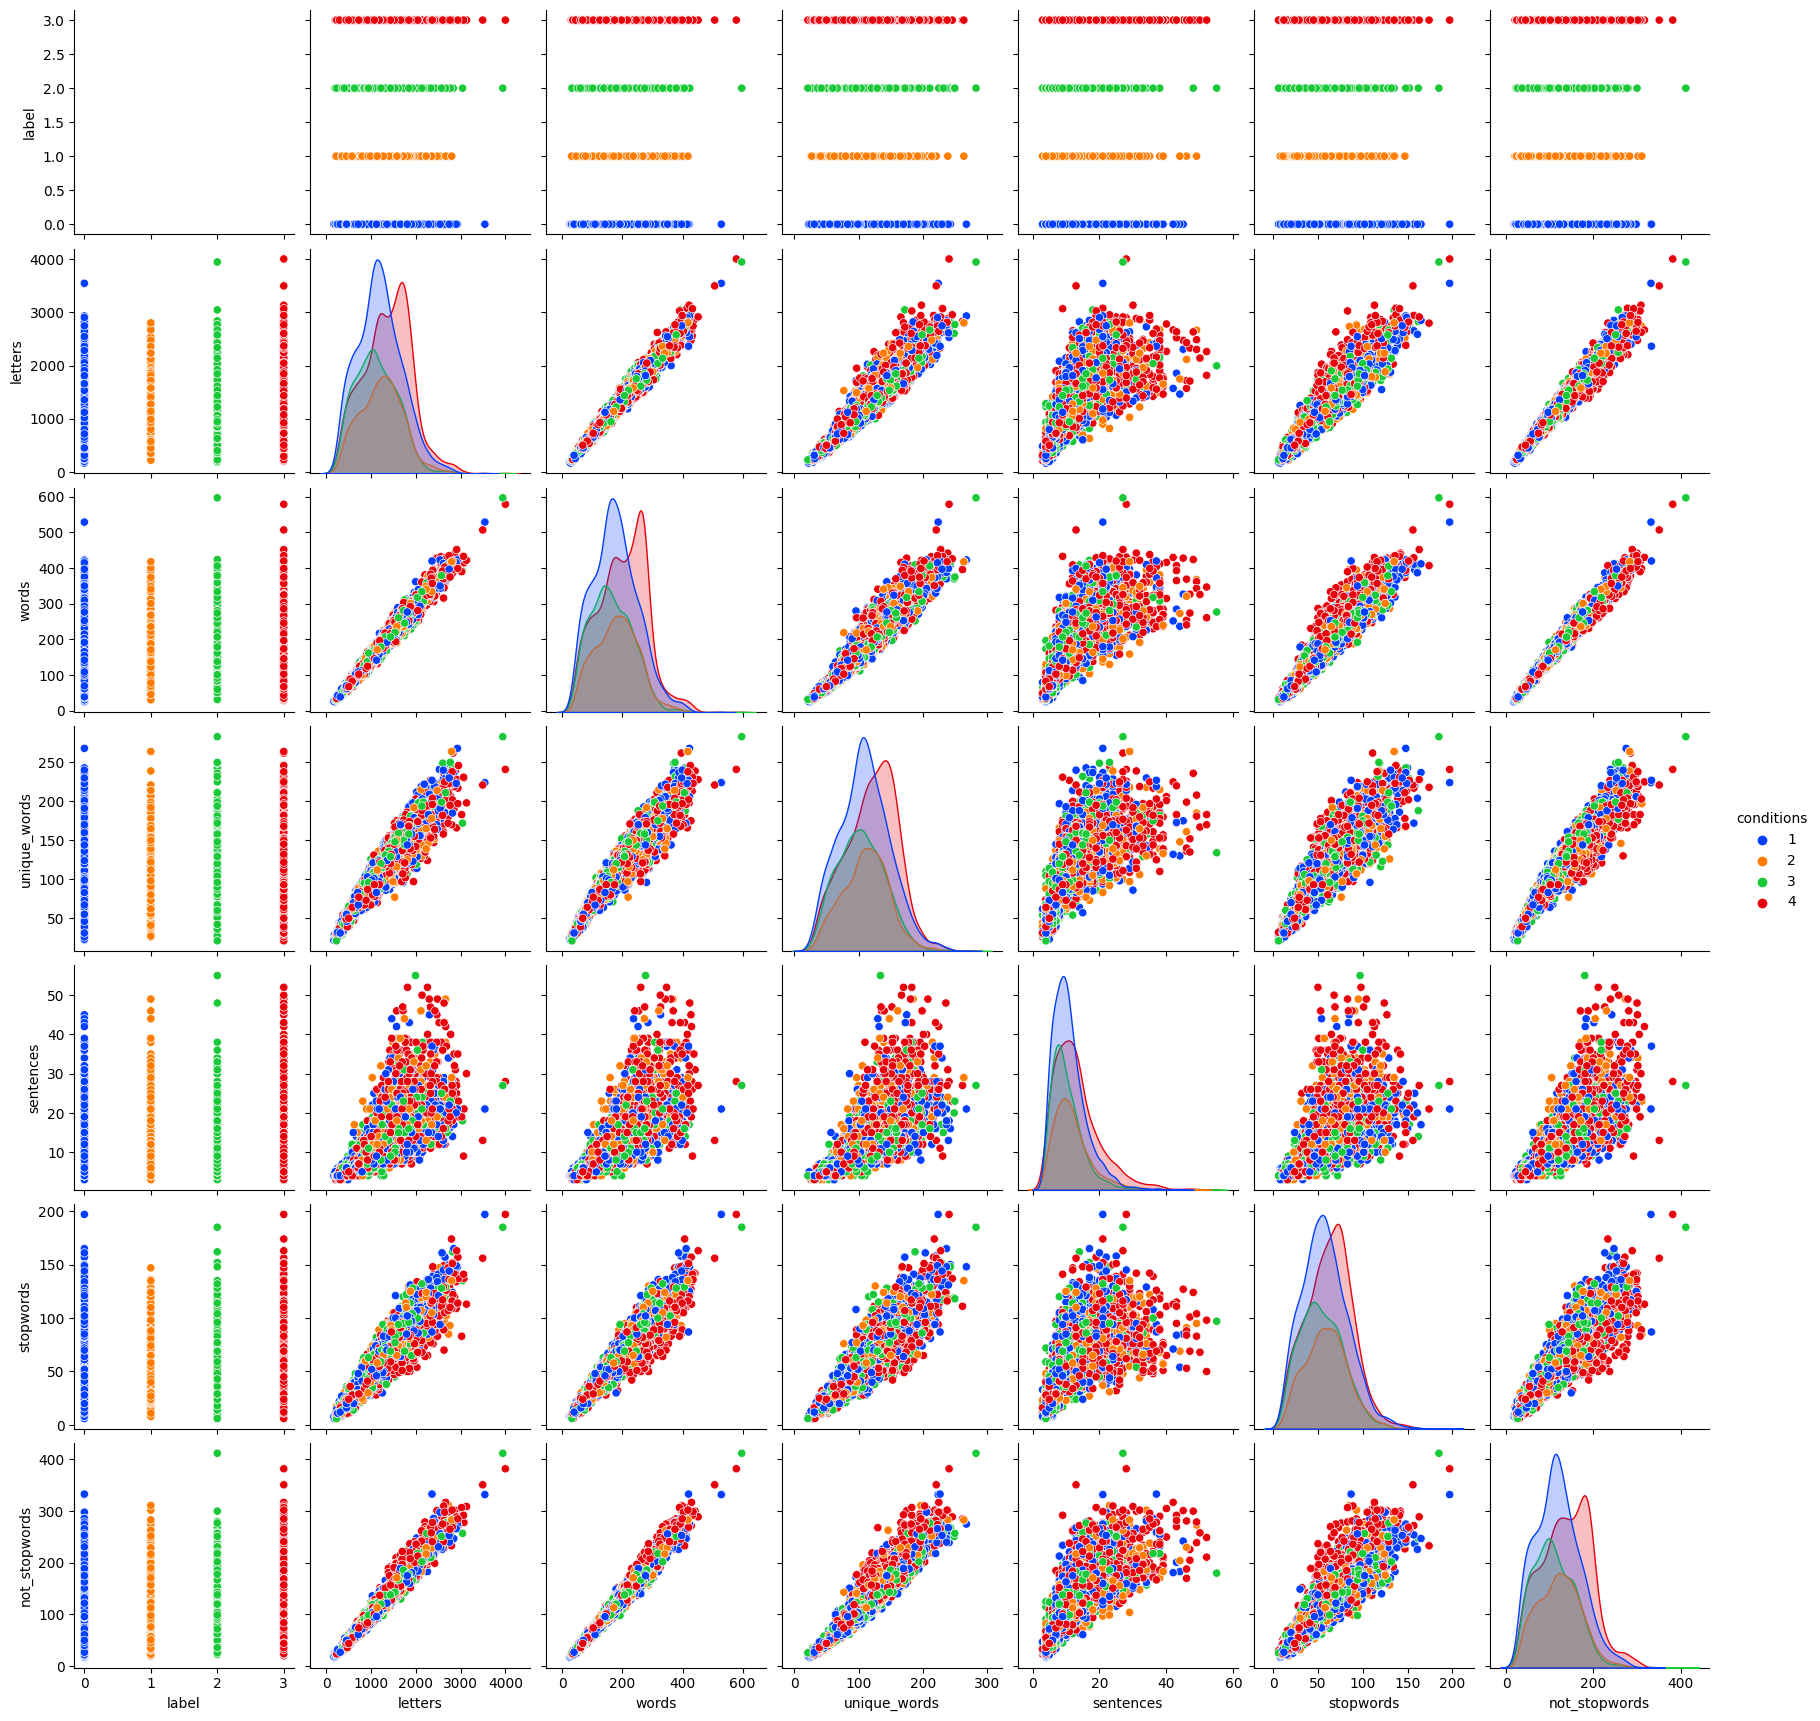

In [16]:
plt.figure(figsize=(12,6))
sns.pairplot(data=tmp.drop(columns=['essay_id','full_text']), hue='conditions', palette='bright')

### Data Cleaning

In [17]:
def Cleaning(text):
    tokens = []
    
    text = text.split()
    for token in text:
        if token not in stop_words:
            tokens.append(token)
    return " ".join(tokens)

In [18]:
def dataPreprocessing(x):
    
    x = x.lower()
    
    x = re.sub('\s+', ' ', x)
    x = re.sub('\d+', '', x)
    x = re.sub('\(d+','', x)
    
    x = re.sub(r'\.+', '.',x)
    x = re.sub(r'\,+', ',',x)
    # 
    
    x = Cleaning(x)
    
    x = x.strip()
    return x 

In [19]:
#train = pl.from_pandas(df_train)
#tmp = train.with_columns(
#     pl.col('full_text').map_elements(lambda x: dataPreprocessing(x))
#        )
#df_train = tmp.to_pandas()

In [20]:
df_train = df_train.reset_index(drop=True)

### Word Cloud

**Label: 0 [neoplasms]**

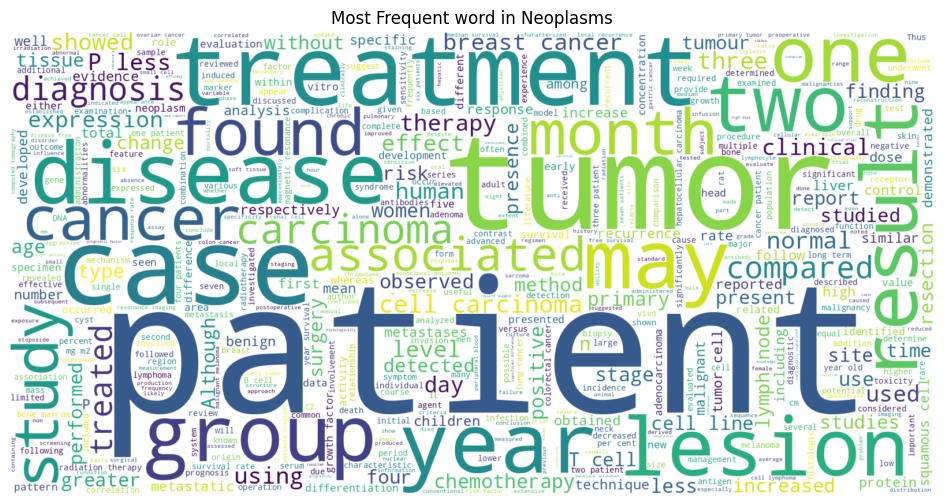

In [21]:
from wordcloud import WordCloud

plt.figure(figsize=(12,6))
plt.title('Most Frequent word in Neoplasms')
wc = WordCloud(background_color='white', max_words = 500, width=1600, height=800, contour_width=10,contour_color='steelblue').generate(" ".join(df_train[df_train['label'] == 0]['full_text']))
plt.axis(False)
plt.imshow(wc, interpolation='bilinear')

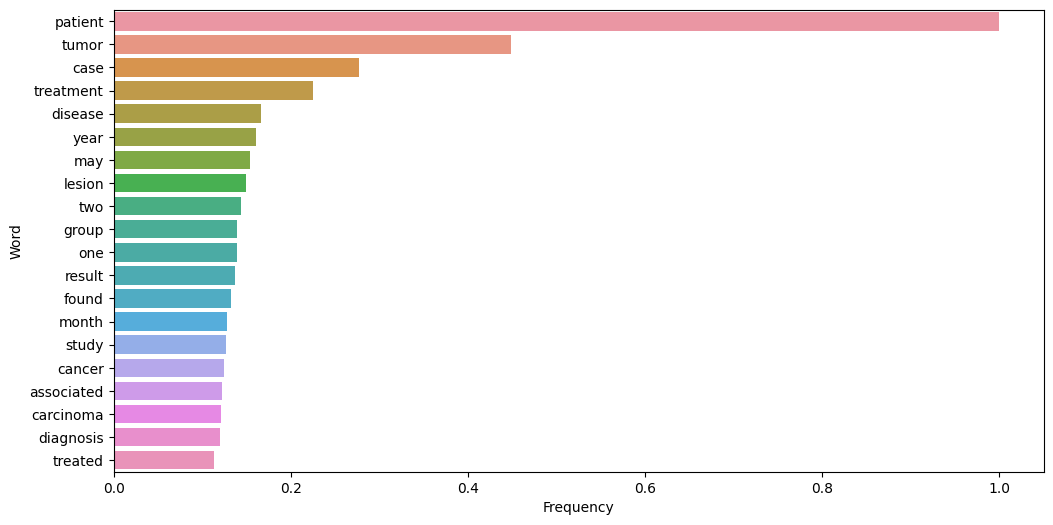

In [22]:
df_wc = pd.DataFrame(wc.words_.items(), columns=['Word', 'Frequency'])
plt.figure(figsize=(12,6))
tmp = df_wc.head(20)
sns.barplot(x=tmp['Frequency'], y=tmp['Word'])
plt.show()

**Label: 1 [digestive system diseases]**

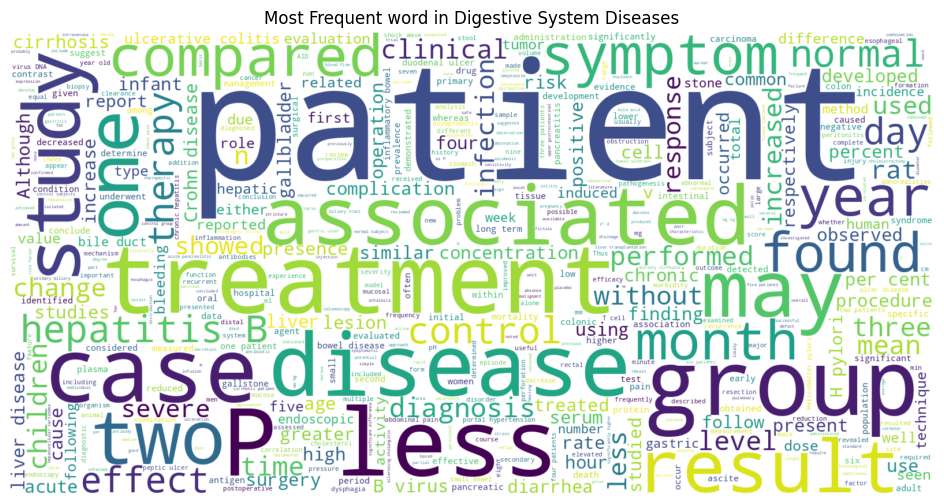

In [23]:
plt.figure(figsize=(12,6))
plt.title('Most Frequent word in Digestive System Diseases')
wc = WordCloud(background_color='white', max_words = 500, width=1600, height=800, contour_width=10,contour_color='steelblue').generate(" ".join(df_train[df_train['label'] == 1]['full_text']))
plt.axis(False)
plt.imshow(wc, interpolation='bilinear') 

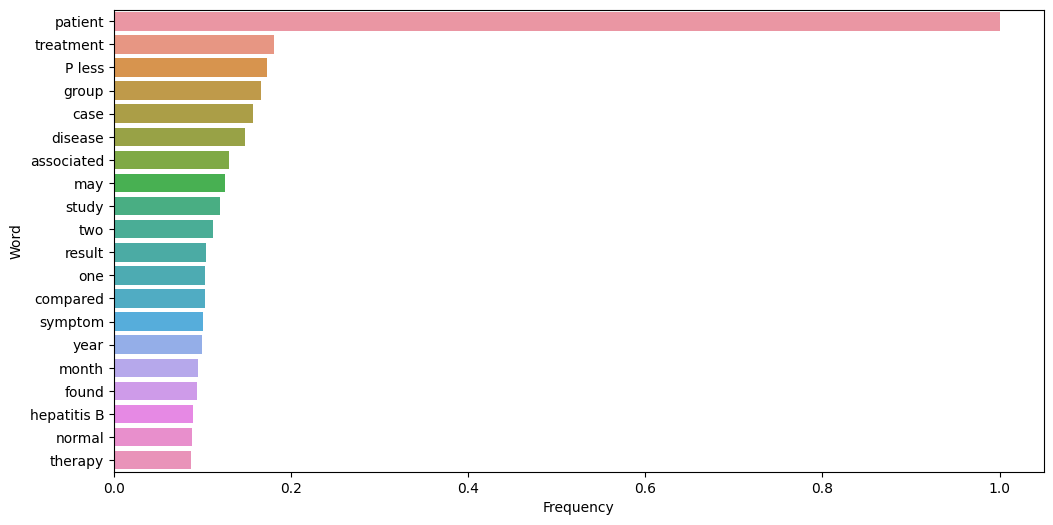

In [24]:
df_wc = pd.DataFrame(wc.words_.items(), columns=['Word', 'Frequency'])
plt.figure(figsize=(12,6))
tmp = df_wc.head(20)
sns.barplot(x=tmp['Frequency'], y=tmp['Word'])
plt.show()

**Label: 2 [nervous system diseases]**

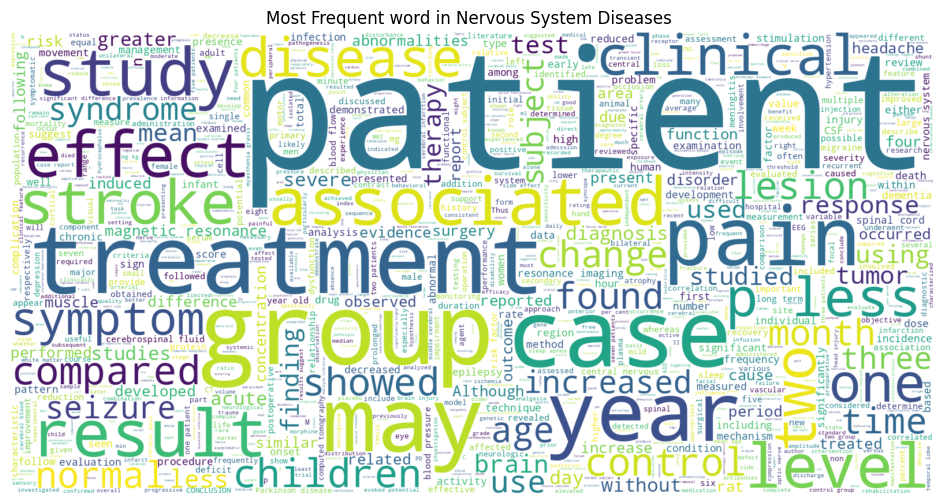

In [25]:
plt.figure(figsize=(12,6))
plt.title("Most Frequent word in Nervous System Diseases ")
wc = WordCloud(background_color='white', max_words = 1000, width=1600, height=800, contour_width=10,contour_color='steelblue').generate(" ".join(df_train[df_train['label'] == 2]['full_text']))
plt.axis(False)
plt.imshow(wc, interpolation='bilinear')

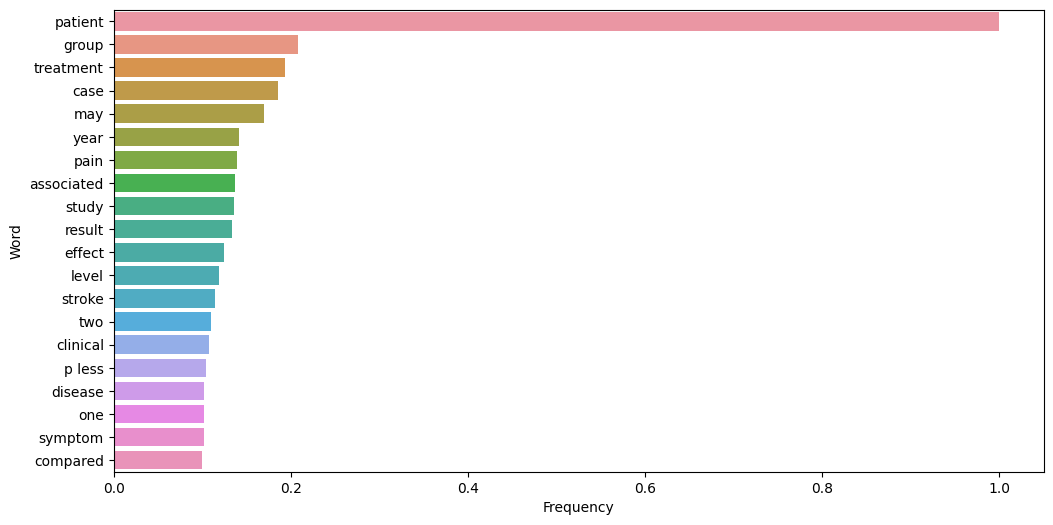

In [26]:
df_wc = pd.DataFrame(wc.words_.items(), columns=['Word', 'Frequency'])
plt.figure(figsize=(12,6))
tmp = df_wc.head(20)
sns.barplot(x=tmp['Frequency'], y=tmp['Word'])
plt.show()

**Label: 3 [cardiovascular diseases]**

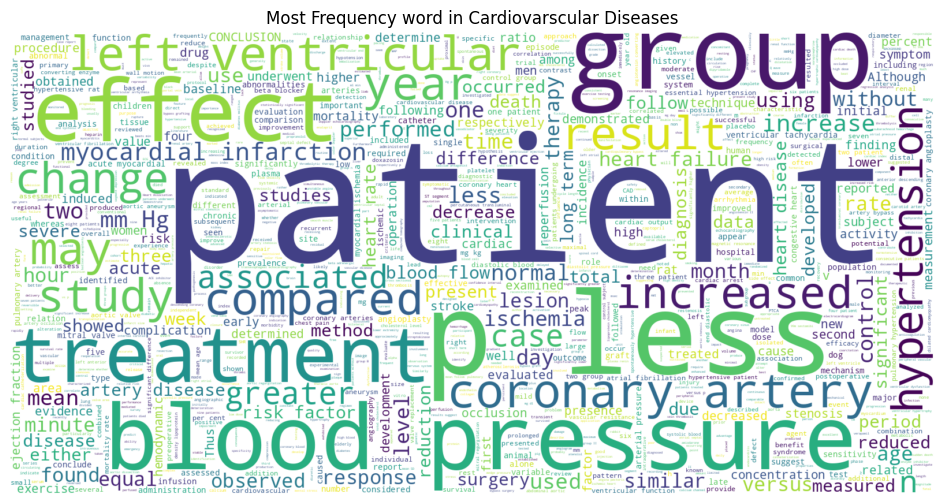

In [27]:
plt.figure(figsize=(12,6))
plt.title("Most Frequency word in Cardiovarscular Diseases")
wc = WordCloud(background_color='white', max_words = 1000, width=1600, height=800, contour_width=10,contour_color='steelblue').generate(" ".join(df_train[df_train['label'] == 3]['full_text']))
plt.axis(False)
plt.imshow(wc, interpolation='bilinear') 

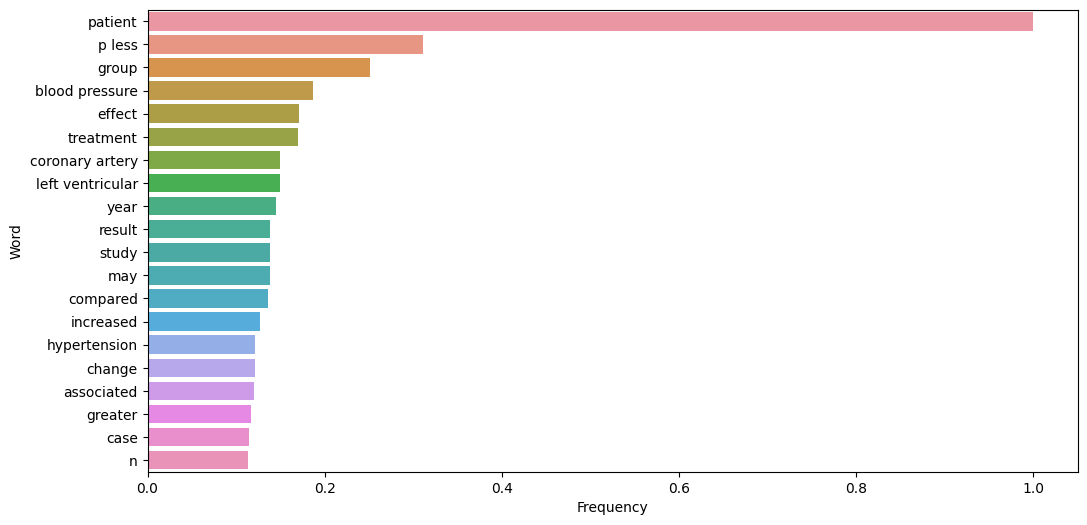

In [28]:
df_wc = pd.DataFrame(wc.words_.items(), columns=['Word', 'Frequency'])
plt.figure(figsize=(12,6))
tmp = df_wc.head(20)
sns.barplot(x=tmp['Frequency'], y=tmp['Word'])
plt.show()

### Topic Modeling

In [29]:
!pip install -q sentence_transformers
!pip install -q bertopic

In [30]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

**Embedding Model**

In [31]:
embedding_model = SentenceTransformer('hkunlp/instructor-base') # Extract Embedding Layers
embeddings = embedding_model.encode(df_train['full_text'], show_progress_bar = True, batch_size = 128)
print(embeddings.shape)

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/66.2k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

...

1_Pooling/config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

2_Dense/config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

(9633, 768)


In [32]:
# UMAP
umap_model = UMAP(n_neighbors=30, n_components=10, min_dist = 0.0, metric='cosine', random_state=config['SEED'])

# Clustering
min_cluster_size = 100

hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size,
                       metric='euclidean', cluster_selection_method='eom', prediction_data=True)

top_n_words = 25
vectorizer_model = CountVectorizer(ngram_range = (1,4),stop_words="english",min_df = 2,)
representation_model = KeyBERTInspired(top_n_words=top_n_words, nr_repr_docs=10, random_state=config['SEED'])

topic_model = BERTopic(language='english', top_n_words=top_n_words,
                      embedding_model = embedding_model,
                      umap_model = umap_model, hdbscan_model=hdbscan_model,
                      vectorizer_model=vectorizer_model, representation_model = representation_model,
                      calculate_probabilities=False, verbose=True)

topics, _ = topic_model.fit_transform(documents=df_train['full_text'], embeddings=embeddings)

2024-05-17 10:19:39,080 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-05-17 10:20:37,763 - BERTopic - Dimensionality - Completed ✓
2024-05-17 10:20:37,765 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-05-17 10:20:38,963 - BERTopic - Cluster - Completed ✓
2024-05-17 10:20:38,969 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-05-17 10:20:50,656 - BERTopic - Representation - Completed ✓


In [33]:
chart = topic_model.visualize_barchart(top_n_topics=7, n_words=5, width=512)
chart.show()

In [34]:
tmp = df_train.copy()
tmp['topic'] = topics
tmp['topic_keyword'] = tmp['topic'].apply(lambda x: [t[0] for t in topic_model.get_topic(int(x))])

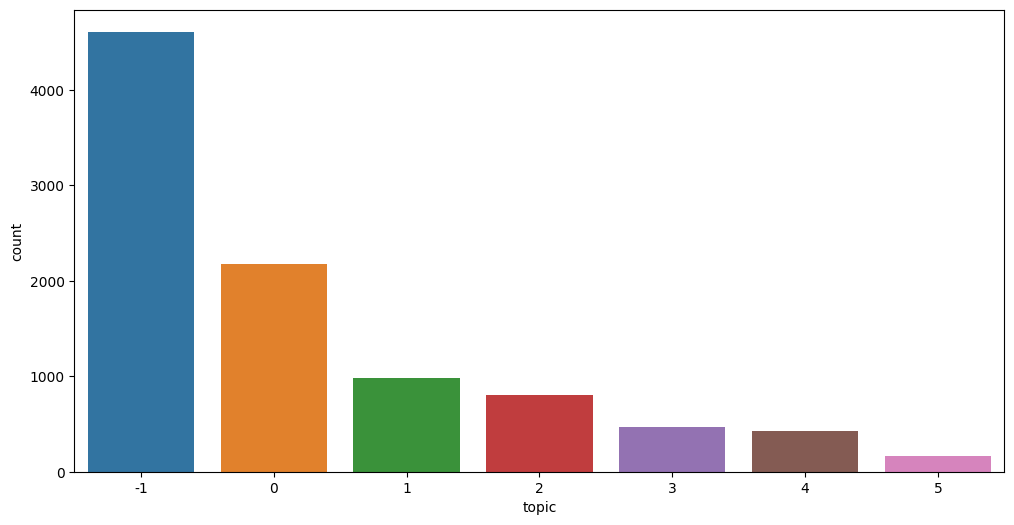

In [35]:
plt.figure(figsize=(12,6))
sns.countplot(x=tmp['topic'])
plt.show()

In [36]:
from IPython.core.display import display, HTML

def highlight_keywords(text, keywords):
    for keyword in keywords:
        text = text.replace(keyword, f'<span style="background-color: blue; color: white;">{keyword}</span>')
    return text

In [37]:
tmp2 = highlight_keywords(tmp.iloc[0]['full_text'], tmp.iloc[0]['topic_keyword'])

display(HTML(tmp2))

In [38]:
tmp2 = highlight_keywords(tmp.iloc[4930]['full_text'], tmp.iloc[4930]['topic_keyword'])

display(HTML(tmp2))

In [39]:
umap_2d = UMAP(n_neighbors=30, n_components=10, min_dist = 0.0, metric='cosine', random_state=config['SEED']).fit_transform(embeddings)
tmp['x'] = umap_2d[:,0]
tmp['y'] = umap_2d[:,1]

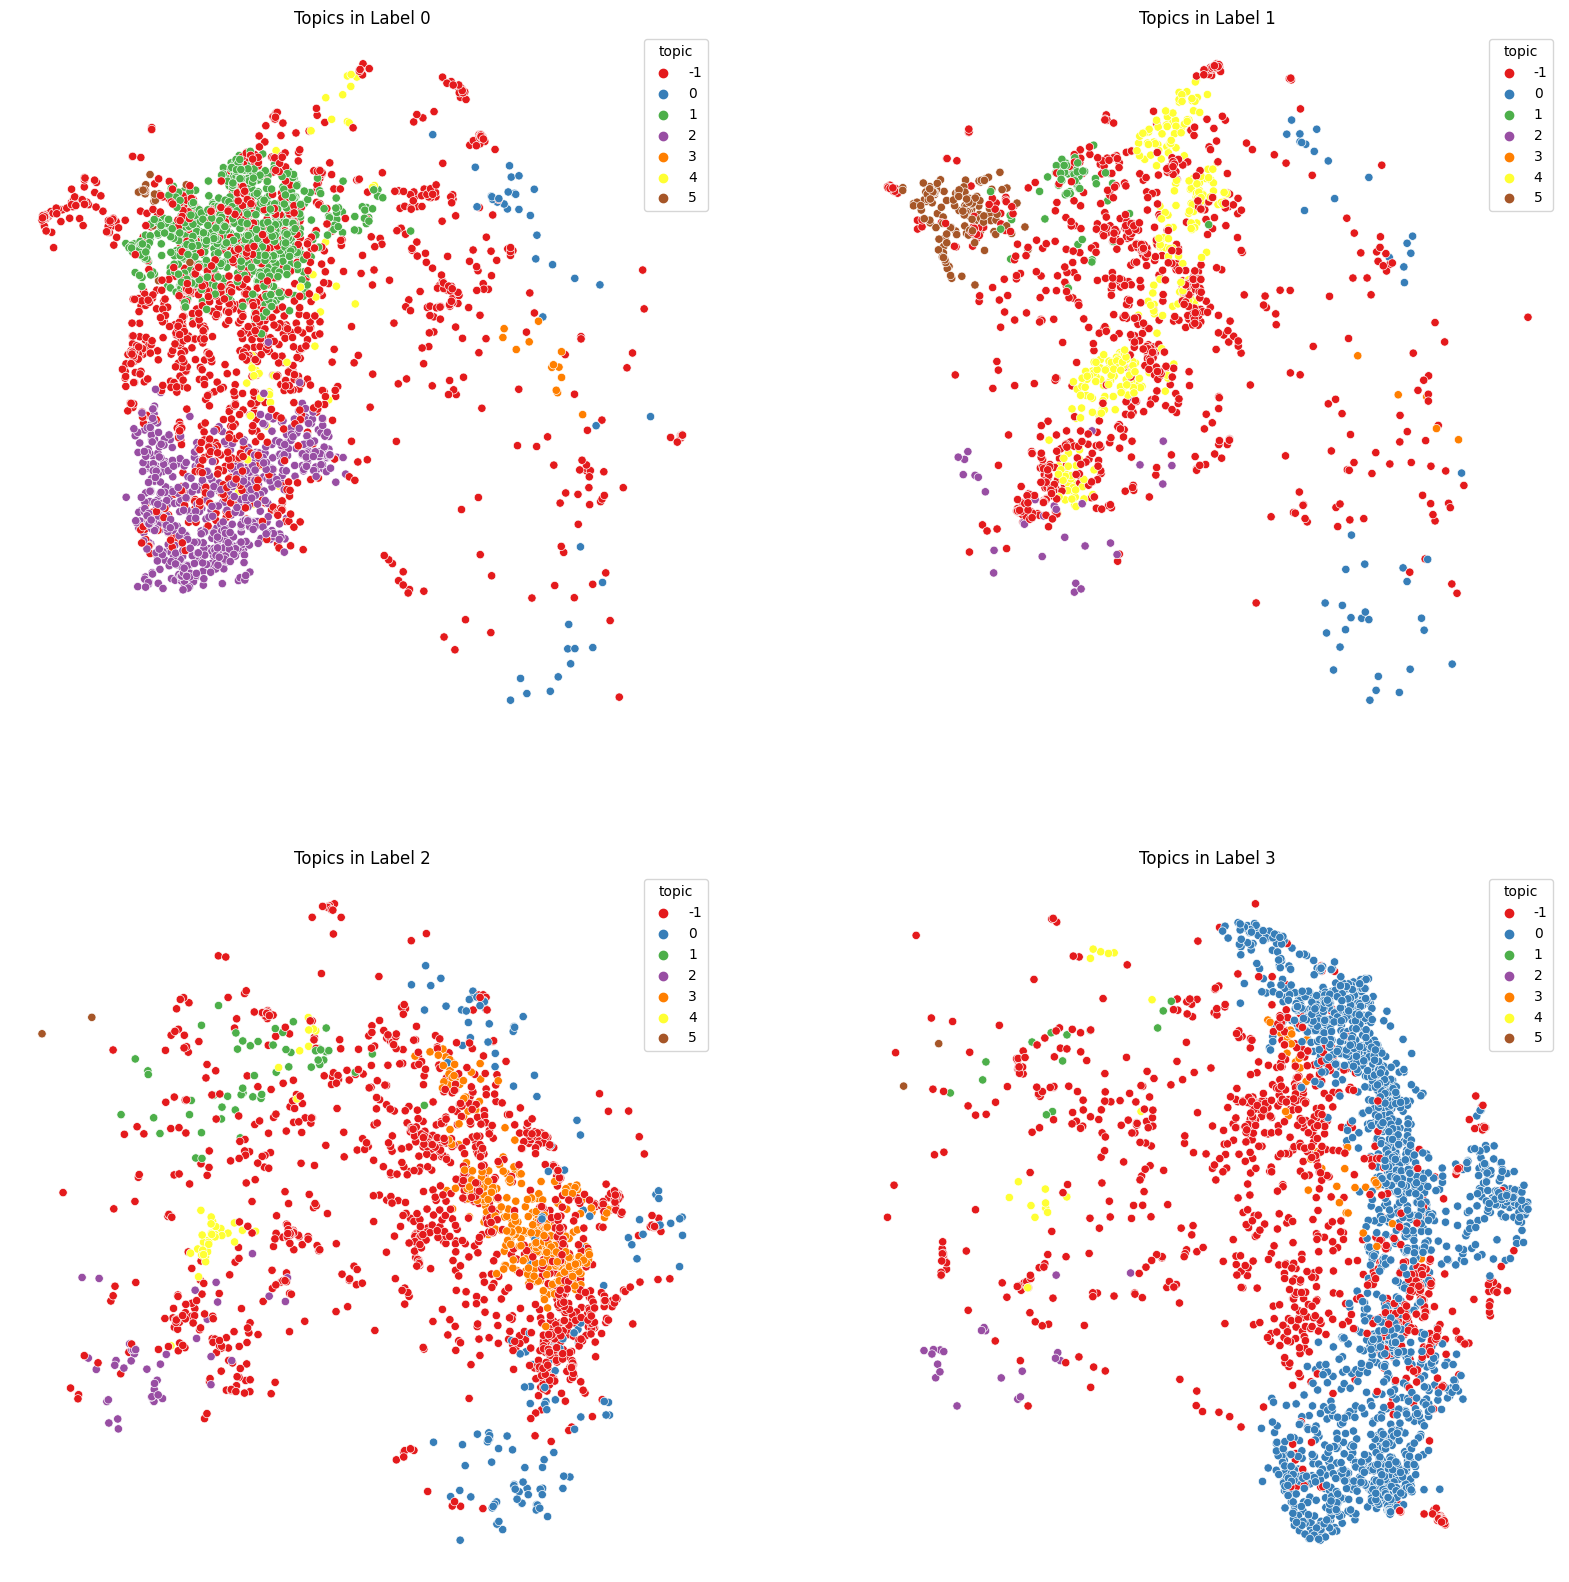

In [40]:
plt.figure(figsize=(20,20))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.title(f'Topics in Label {i}')
    sns.scatterplot(data=tmp[tmp['label'] == i] , x='x',y='y', hue='topic', palette='Set1')
    plt.axis(False)

plt.show()

### Train Deberta Model

In [41]:
skf = StratifiedKFold(n_splits=5)
for i, (_, val_index) in enumerate(skf.split(df_train,df_train['conditions'])):
    df_train.loc[val_index, 'fold'] = i

print('Shape of Train: ', df_train.shape)
print(display(df_train.head()))

Shape of Train:  (9633, 11)


,conditions,full_text,essay_id,label,letters,words,unique_words,sentences,stopwords,not_stopwords,fold
0,4,Catheterization laboratory events and hospital...,0000,3,1687,235,109,7,51,184,0.0
1,2,Hyperplastic polyps seen at sigmoidoscopy are ...,0002,1,1032,143,86,12,46,97,0.0
2,4,Effect of local inhibition of gamma-aminobutyr...,0004,3,2012,276,158,14,84,192,0.0
3,1,Infection during chronic epidural catheterizat...,0005,0,1287,192,111,11,69,123,0.0
4,3,Multiple representations contribute to body kn...,0008,2,1750,274,170,15,118,156,0.0


None


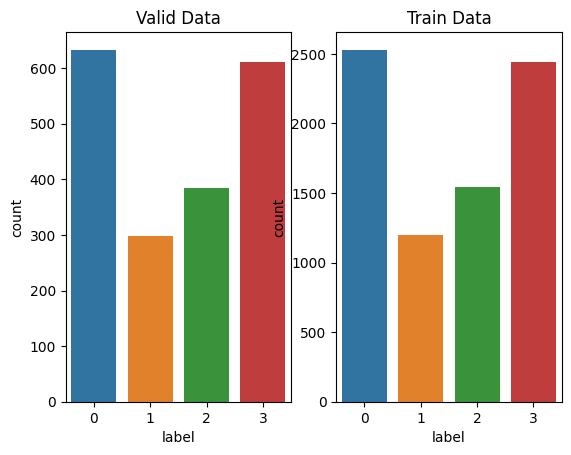

In [42]:
plt.figure()
plt.subplot(1,2,1)
plt.title('Valid Data')
sns.countplot(x=df_train[df_train['fold']==0]['label'])
plt.subplot(1,2,2)
plt.title('Train Data')
sns.countplot(x=df_train[df_train['fold']!=0]['label'])
plt.show()

In [43]:
if config['INFERENCE'] is None:
    tokenizer = AutoTokenizer.from_pretrained(config['PRESET'],  truncation=True, max_length=config['MAX_LEN'], clean_up_tokenization_spaces=False)
    print(tokenizer)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

DebertaV2TokenizerFast(name_or_path='microsoft/deberta-v3-xsmall', vocab_size=128000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}


In [44]:
def preprocess(sample):
    return tokenizer(sample['full_text'])

In [45]:
dataset_t = Dataset.from_pandas(df_train)
dataset_t

Dataset({
    features: ['conditions', 'full_text', 'essay_id', 'label', 'letters', 'words', 'unique_words', 'sentences', 'stopwords', 'not_stopwords', 'fold'],
    num_rows: 9633
})

In [46]:
tokenized = dataset_t.map(preprocess)
tokenized_length = [len(x) for x in tokenized['input_ids']]

Map:   0%|          | 0/9633 [00:00<?, ? examples/s]

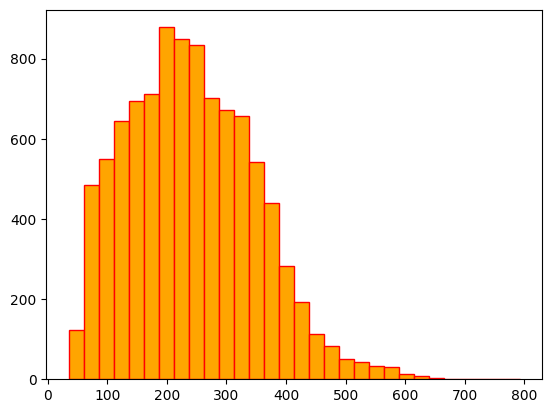

In [47]:
plt.figure()
plt.hist(x=tokenized_length, bins=30, color='orange', edgecolor='red')
plt.show()

In [48]:
training_args = TrainingArguments(
    output_dir = f'/output_v{config["VER"]}',
    per_device_train_batch_size=config['TRAIN_BATCH'],
    per_device_eval_batch_size=config['EVAL_BATCH'],
    num_train_epochs= config['EPOCHS'],
    evaluation_strategy='steps',
    logging_steps = 250,
    save_strategy='steps',
    load_best_model_at_end=True,
    weight_decay= 1e-2, 
    fp16=True,# automatic mixed precision, AMP
    learning_rate=1e-5, # 1e-5 -> 2e-5
    lr_scheduler_type='linear',
    optim='adamw_torch',
    metric_for_best_model='accuracy',
    save_total_limit=1,
    report_to='none',
)

In [49]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    accuracy = accuracy_score(labels, np.argmax(predictions, axis=1))
    f1 = f1_score(labels, np.argmax(predictions, axis=1), average='weighted')
    results = {
        'accuracy': accuracy,
        'f1_score': f1,
    }
    return results

In [50]:
if config['INFERENCE'] is None: 
    model_config = AutoConfig.from_pretrained(config['PRESET'])

    model_config.attention_probs_dropout_prob = 0.0
    model_config.hidden_dropout_prob = 0.0
    model_config.num_labels = 4
    model_config.max_position_embeddings = 512

    model = AutoModelForSequenceClassification.from_pretrained(config['PRESET'], config=model_config)
    
    if config['FREEZING_EMBEDDINGS']:
        print('Freezing embeddings.')
        for param in model.deberta.embeddings.parameters():
            param.requires_grad = False
        
    if config['FREEZE_LAYERS'] > 0:
        print(f'Freezing {config["FREEZE_LAYERS"]} layers')
        for layer in model.deberta.encoder.layer[:config['FREEZE_LAYERS']]:
            for param in layer.parameters():
                param.requires_grad = False


pytorch_model.bin:   0%|          | 0.00/241M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-xsmall and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing embeddings.
Freezing 1 layers


Map (num_proc=2):   0%|          | 0/1927 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7706 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
250,1.340800,1.192529,0.531396,0.419609
500,0.959200,0.892195,0.651271,0.596470
750,0.790900,0.728687,0.760768,0.756205
1000,0.684300,0.649925,0.797094,0.798853
1250,0.594600,0.583824,0.816814,0.816774
1500,0.561200,0.538666,0.822522,0.822385
1750,0.538300,0.550388,0.831344,0.830220
2000,0.515900,0.541393,0.828230,0.828212
2250,0.427500,0.530224,0.830306,0.829626
2500,0.485700,0.519613,0.834458,0.835044


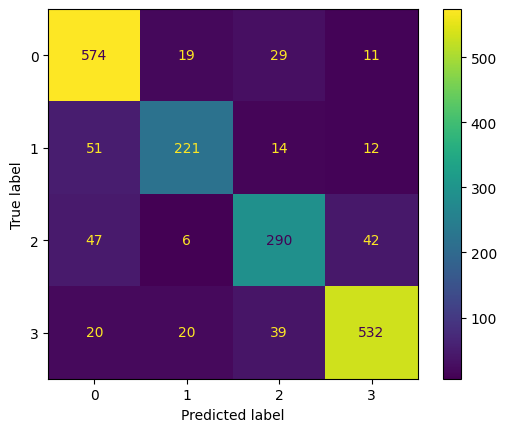

Map (num_proc=2):   0%|          | 0/1927 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7706 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
250,0.528400,0.469156,0.843799,0.845909
500,0.497300,0.425135,0.861962,0.861463
750,0.458300,0.397487,0.866632,0.867564
1000,0.443400,0.404367,0.869746,0.867901
1250,0.426700,0.391069,0.869227,0.868847
1500,0.416600,0.415668,0.864556,0.864470
1750,0.430600,0.436234,0.869746,0.869181
2000,0.432800,0.414864,0.867151,0.866927
2250,0.327500,0.417771,0.861443,0.861839
2500,0.385800,0.425607,0.862999,0.862330


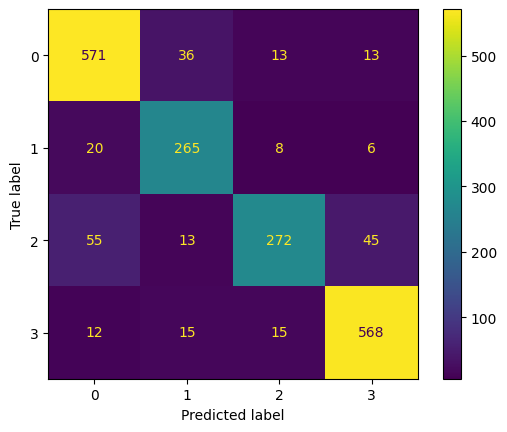

Map (num_proc=2):   0%|          | 0/1927 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7706 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
250,0.447300,0.430425,0.859886,0.860100
500,0.452900,0.486060,0.849507,0.846647
750,0.426400,0.429749,0.856772,0.857257
1000,0.404900,0.441799,0.856772,0.856467
1250,0.361800,0.498401,0.858848,0.857084
1500,0.391400,0.506648,0.840166,0.837756
1750,0.397200,0.491216,0.853659,0.852049
2000,0.383200,0.475515,0.850545,0.849251
2250,0.311300,0.509026,0.848469,0.846177
2500,0.311700,0.476059,0.848988,0.848563


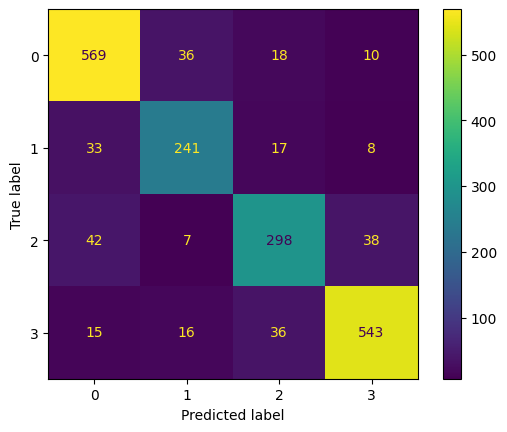

Map (num_proc=2):   0%|          | 0/1926 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7707 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
250,0.374200,0.393863,0.874870,0.874016
500,0.432600,0.409009,0.869159,0.869426
750,0.418600,0.403664,0.871755,0.870733
1000,0.399600,0.412532,0.866044,0.866322
1250,0.343700,0.425560,0.864486,0.864198
1500,0.363700,0.473488,0.855140,0.854476
1750,0.354800,0.447288,0.860332,0.860775
2000,0.344100,0.459423,0.860852,0.859774
2250,0.305800,0.449771,0.863448,0.862136
2500,0.327800,0.458509,0.859813,0.858951


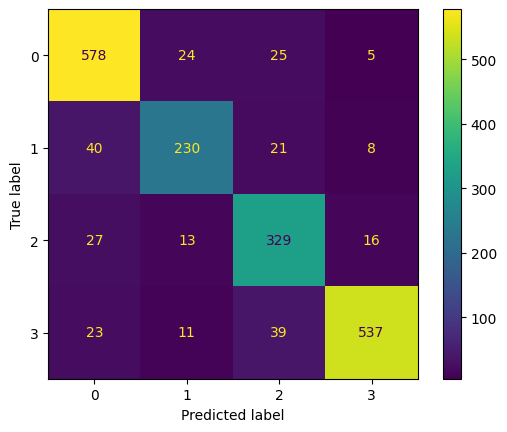

Map (num_proc=2):   0%|          | 0/1926 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7707 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
250,0.338400,0.342166,0.893562,0.893795
500,0.425600,0.366696,0.888889,0.889187
750,0.453700,0.344263,0.883697,0.881792
1000,0.413200,0.351327,0.872274,0.873300
1250,0.368400,0.344343,0.888889,0.888962
1500,0.355900,0.348219,0.876947,0.877743
1750,0.350900,0.382665,0.881620,0.881077
2000,0.364200,0.344178,0.874870,0.874775
2250,0.300500,0.357573,0.877985,0.877327
2500,0.324500,0.354463,0.881620,0.880840


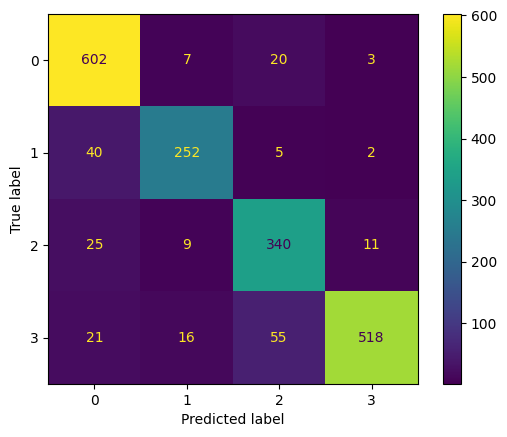

In [51]:
if config['INFERENCE'] is None:
    all_oof = []
    all_true = []
    fold_metrics = []
    
    for i in range(5):
        train = df_train[df_train['fold'] != i]
        valid = df_train[df_train['fold'] == i]
    
        dataset_v = Dataset.from_pandas(valid)
        dataset_t = Dataset.from_pandas(train)
        dataset = Dataset.from_pandas(df_train)
        # Valid Dataset
        tokenized_dataset_v = dataset_v.map(preprocess, num_proc=2, 
                         remove_columns=['essay_id', 'full_text', 'conditions'])
        # Train Dataset
        tokenized_dataset_t = dataset_t.map(preprocess, num_proc=2, 
                        remove_columns=['essay_id', 'full_text', 'conditions'])
        trainer = Trainer(
                 model = model,
                 args = training_args,
                 tokenizer = tokenizer,
                 train_dataset = tokenized_dataset_t,
                 eval_dataset = tokenized_dataset_v,
                 data_collator = DataCollatorWithPadding(tokenizer),
                 compute_metrics=compute_metrics
                 )

        trainer.train()
        log_history = trainer.state.log_history
        fold_metrics.append(log_history)
        
        
        y_true = valid['label'].values
        all_true.append(y_true)
        predictions = trainer.predict(tokenized_dataset_v).predictions
        all_oof.append(np.argmax(predictions, axis=1))
        cm = confusion_matrix(y_true, np.argmax(predictions, axis=1), labels=[x for x in range(4)])
        draw_cm = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=[x for x in range(4)])
        draw_cm.plot()
        plt.show()

        trainer.save_model(f'DeBerta_XSmall_v{config["VER"]}_Fold{i}')
        del train, valid, tokenized_dataset_t, tokenized_dataset_v
        clean_memory()
        
else:
    None

**Traing Loss & Valid Loss**

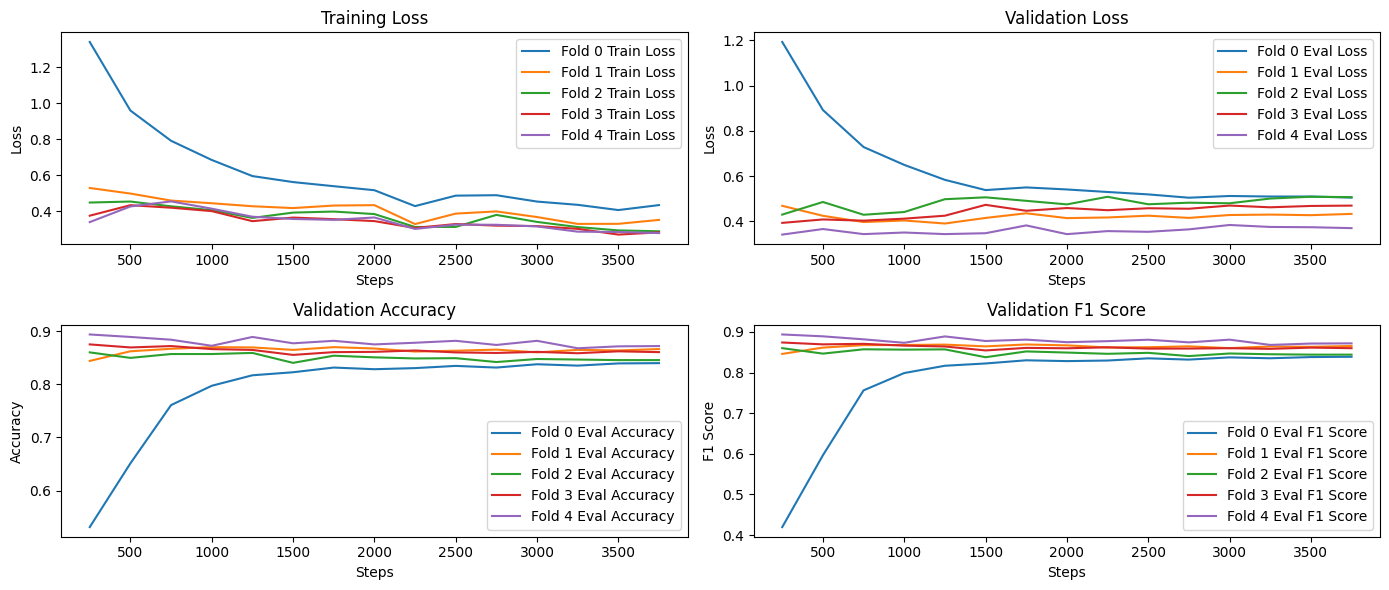

In [52]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 6))

for i, fold_log in enumerate(fold_metrics):
    train_loss = [log['loss'] for log in fold_log if 'loss' in log]
    eval_loss = [log['eval_loss'] for log in fold_log if 'eval_loss' in log]
    steps = [log['step'] for log in fold_log if 'loss' in log]
    eval_steps = [log['step'] for log in fold_log if 'eval_loss' in log]
    eval_accuracy = [log['eval_accuracy'] for log in fold_log if 'eval_accuracy' in log]
    eval_f1_score = [log['eval_f1_score'] for log in fold_log if 'eval_f1_score' in log]
    
    ax1.plot(steps, train_loss, label=f'Fold {i} Train Loss')
    ax2.plot(eval_steps, eval_loss, label=f'Fold {i} Eval Loss')

    ax3.plot(eval_steps, eval_accuracy, label=f'Fold {i} Eval Accuracy')
    ax4.plot(eval_steps, eval_f1_score, label=f'Fold {i} Eval F1 Score')

ax1.set_title('Training Loss')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.set_title('Validation Loss')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Loss')
ax2.legend()

ax3.set_title('Validation Accuracy')
ax3.set_xlabel('Steps')
ax3.set_ylabel('Accuracy')
ax3.legend()

ax4.set_title('Validation F1 Score')
ax4.set_xlabel('Steps')
ax4.set_ylabel('F1 Score')
ax4.legend()

plt.tight_layout()
plt.show()

**Overall Accuracy & F1 Score**

In [53]:
accuracy = accuracy_score(np.concatenate(all_true), np.concatenate(all_oof)) * 100
f1 = f1_score(np.concatenate(all_true), np.concatenate(all_oof), average='weighted') * 100

print(f'Overall Accuracy Score is {accuracy}%')
print(f'Overall F1 Score is {f1}%')

Overall Accuracy Score is 86.47358040070591%
Overall F1 Score is 86.45255854322038%
